In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [2]:
import numpy as np
import pandas as pd
import sys
import os
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split  # 데이터 분리
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

# <실습계획>
- 레드와인 등급 예측
1. 데이터셋 확보 및 전처리
    - csv -> 결측치 확인 -> 독립변수와 타겟변수 분리 -> 독립변수 스케일 조정 + 타겟변수 원핫인코딩 -> 훈련셋/테스트셋 분리
2. 모델 구성 (입력층 11, 출력 6개 - pd.get_dumies / 출력 9 - to_categorical) 레이어 4개층
3. 모델 학습과정 설정 
4. 학습하기 (callbacks 사용)
5. 모델 평가하기 (그래프, 평가, 교차표)
6. 모델 사용 및 저장

In [49]:
# 데이터 읽어오기
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine
# fixed acidity : 고정 산도
# volatile acidity : 휘발성 산도
# citric acid : 시트르산
# residual sugar : 잔류 당분
# chlorides : 염화물
# free sulfur dioxide : 자유 이산화황
# total sulfur dioxide : 총 이산화황
# density : 밀도
# pH
# sulphates : 황산염
# alcohol
# quality : 0 ~ 10(높을 수록 좋은 품질)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [50]:
redwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [51]:
redwine['quality'].value_counts()  # 5, 6 등급만 잘 맞출 것 같은 데이터 셋이다

5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64

In [100]:
X_data = redwine.iloc[:,:-1].values
y_data = redwine.iloc[:,-1].values
X_data.shape, y_data.shape

((1599, 11), (1599,))

In [128]:
# X 스케일 , Y 원핫인코딩 (to_cate)
scaler_X = MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)

y_data_onehot = to_categorical(y_data)
scaled_X_data.shape, y_data_onehot.shape


((1599, 11), (1599, 9))

In [101]:
# X 스케일 , Y 원핫인코딩 (get_dummies)
scaler_X = MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)

y_data_onehot = pd.get_dummies(y_data).values
scaled_X_data.shape, y_data_onehot.shape


((1599, 11), (1599, 6))

In [129]:
# 훈련셋, 테스트셋 분리
X_train,X_test, y_train, y_test = train_test_split(scaled_X_data, y_data_onehot, 
                                                    test_size=0.3, # 테스트셋 비율
                                                    shuffle=True, 
                                                    random_state=7,
                                                    stratify=y_data_onehot) # 층화추출
X_train.shape, X_test.shape, y_train.shape,  y_test.shape 

((1119, 11), (480, 11), (1119, 9), (480, 9))

In [135]:
# 모델 구성
model = Sequential([
    Input(shape=(11,)),
    Dense(units=1024, activation='relu'),
    Dropout(0.1),
    Dense(units=512, activation='relu'),
    Dropout(0.1),
    Dense(units=128, activation='relu'),
    Dense(units=9, activation='softmax'),
])

In [136]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 1024)              12288     
                                                                 
 dropout_4 (Dropout)         (None, 1024)              0         
                                                                 
 dense_37 (Dense)            (None, 512)               524800    
                                                                 
 dropout_5 (Dropout)         (None, 512)               0         
                                                                 
 dense_38 (Dense)            (None, 128)               65664     
                                                                 
 dense_39 (Dense)            (None, 9)                 1161      
                                                                 
Total params: 603,913
Trainable params: 603,913
Non-tr

In [137]:
# 모델 학습과정 설정
model.compile(loss = 'categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [138]:
# 콜백함수 설정

earlystopping = EarlyStopping(monitor='val_accuracy', patience= 40)
saving_folder = './model09/'
if not os.path.exists(saving_folder):
    os.mkdir(saving_folder)
file = saving_folder + 'wine-{epoch:03d}-val_acc{val_accuracy:.4f}.h5'

checkpoint = ModelCheckpoint(monitor='val_accuracy',
                             filepath=file,
                            save_best_only=True,
                            verbose=1)


In [139]:
%%time
# 모델 학습하기 
hist = model.fit(X_train, y_train,
                 batch_size= 200, epochs= 100, verbose=1,
                 validation_split=0.3,
                callbacks=[earlystopping,checkpoint]
                )

Epoch 1/100
1/4 [======>.......................] - ETA: 1s - loss: 2.2104 - accuracy: 0.0450
Epoch 1: val_accuracy improved from -inf to 0.40179, saving model to ./model09\wine-001-val_acc0.4018.h5
4/4 [==============================] - 1s 81ms/step - loss: 2.0351 - accuracy: 0.3346 - val_loss: 1.7558 - val_accuracy: 0.4018
Epoch 2/100
1/4 [======>.......................] - ETA: 0s - loss: 1.7625 - accuracy: 0.3750
Epoch 2: val_accuracy did not improve from 0.40179
4/4 [==============================] - 0s 25ms/step - loss: 1.5412 - accuracy: 0.4368 - val_loss: 1.3812 - val_accuracy: 0.4018
Epoch 3/100
1/4 [======>.......................] - ETA: 0s - loss: 1.2809 - accuracy: 0.4600
Epoch 3: val_accuracy improved from 0.40179 to 0.50595, saving model to ./model09\wine-003-val_acc0.5060.h5
4/4 [==============================] - 0s 34ms/step - loss: 1.3001 - accuracy: 0.4840 - val_loss: 1.3051 - val_accuracy: 0.5060
Epoch 4/100
1/4 [======>.......................] - ETA: 0s - loss: 1.2974

1/4 [======>.......................] - ETA: 0s - loss: 0.8275 - accuracy: 0.6250
Epoch 59: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 27ms/step - loss: 0.7949 - accuracy: 0.6462 - val_loss: 0.9944 - val_accuracy: 0.5893
Epoch 60/100
4/4 [==============================] - ETA: 0s - loss: 0.7957 - accuracy: 0.6590
Epoch 60: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 31ms/step - loss: 0.7957 - accuracy: 0.6590 - val_loss: 0.9882 - val_accuracy: 0.5923
Epoch 61/100
1/4 [======>.......................] - ETA: 0s - loss: 0.7799 - accuracy: 0.6550
Epoch 61: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 23ms/step - loss: 0.7918 - accuracy: 0.6577 - val_loss: 0.9971 - val_accuracy: 0.5952
Epoch 62/100
1/4 [======>.......................] - ETA: 0s - loss: 0.7093 - accuracy: 0.7050
Epoch 62: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 22m

Epoch 89/100
1/4 [======>.......................] - ETA: 0s - loss: 0.7502 - accuracy: 0.7050
Epoch 89: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 22ms/step - loss: 0.7269 - accuracy: 0.6871 - val_loss: 1.0148 - val_accuracy: 0.5952
Epoch 90/100
1/4 [======>.......................] - ETA: 0s - loss: 0.6709 - accuracy: 0.6900
Epoch 90: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 23ms/step - loss: 0.7108 - accuracy: 0.6986 - val_loss: 1.0127 - val_accuracy: 0.5952
Epoch 91/100
1/4 [======>.......................] - ETA: 0s - loss: 0.7586 - accuracy: 0.6650
Epoch 91: val_accuracy did not improve from 0.62500
4/4 [==============================] - 0s 22ms/step - loss: 0.7166 - accuracy: 0.6845 - val_loss: 1.0163 - val_accuracy: 0.6042
Epoch 92/100
1/4 [======>.......................] - ETA: 0s - loss: 0.7432 - accuracy: 0.6600
Epoch 92: val_accuracy did not improve from 0.62500
4/4 [===========================

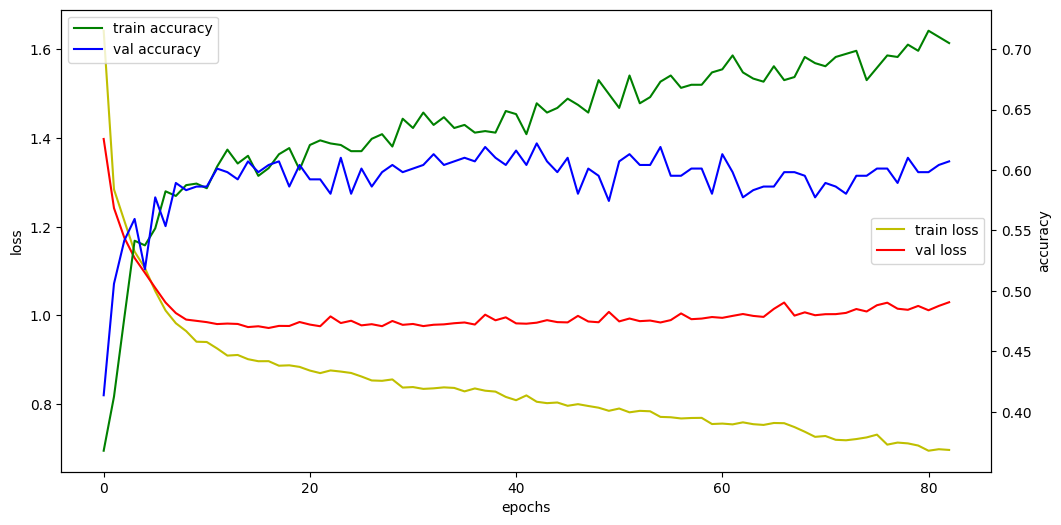

In [116]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()



In [110]:
# 평가하기

loss_and_metrics = model.evaluate(X_test, y_test, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

# 교차표
y_hat = model.predict(X_test).argmax(axis=1)
crosstab = pd.crosstab(y_test.argmax(axis=1), y_hat,
                      rownames=['실제값'], colnames=['예측값'])
display(crosstab)

loss : 1.0832293033599854
accuracy : 0.59375
15/15 [==============================] - 0s 3ms/step


예측값,1,2,3,4,5
실제값,,,,,
0,0,2,1,0,0
1,0,9,5,2,0
2,0,143,54,7,0
3,1,55,106,29,1
4,0,5,18,36,1
5,0,0,3,2,0


In [117]:
# 모델 저장
model.save('model/09_wineclass.h5')

In [124]:
# 모델 불러오기
model2 = load_model('model09/wine-017-val_acc0.6280.h5')

In [126]:
X_test.shape, y_test.shape

((480, 11), (480, 6))

In [140]:
# 평가하기

loss_and_metrics = model.evaluate(X_test, y_test, batch_size=100, verbose=0)
print('현재 모델의 loss :', loss_and_metrics[0])
print('현재 모델의 accuracy :', loss_and_metrics[1])
loss_and_metrics2 = model2.evaluate(X_test, y_test, batch_size=100, verbose=0)
print('저장된 베스트 모델의 loss :', loss_and_metrics2[0])
print('저장된 베스트 모델의  accuracy :', loss_and_metrics2[1])


현재 모델의 loss : 1.0510964393615723
현재 모델의 accuracy : 0.6041666865348816
저장된 베스트 모델의 loss : 1.0243644714355469
저장된 베스트 모델의  accuracy : 0.5791666507720947
